1. How do financial and non-financial firms differ?
2. How do main industries differ across all 13 ratios?
3. Which industries are strongest/weakest in profitability, leverage, liquidity, and efficiency?
4. What conclusions can be written beyond only the regression findings?

**Cell 1 - Notebook title**

In [1]:
# ============================================================
# 06_industry_and_ratio_deepdive
# Master Thesis: Financial vs Non-financial + Industry Ratio Analysis
# ============================================================

print("06_industry_and_ratio_deepdive notebook started.")

06_industry_and_ratio_deepdive notebook started.


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount("/content/drive")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries loaded.")

Mounted at /content/drive
Libraries loaded.


**Cell 3 - Set paths and load final ratio-ready dataset**

In [5]:
BASE_PATH = "/content/drive/MyDrive/IBS_7_Thesis/Python Files"

DATA_PATH = os.path.join(
    BASE_PATH,
    "cleaning_audit_outputs",
    "DE_thesis_analysis_final_ratio_ready.csv"
)

OUT_DIR = os.path.join(BASE_PATH, "analysis_outputs", "06_industry_and_ratio_deepdive")
FIG_DIR = os.path.join(OUT_DIR, "figures")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset loaded.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded.
Rows: 91617
Columns: 41


,company_key,Name,Register-ID,North Data URL,financial_date,financial_year,status_group,industry_raw,industry_label,wz_code_detailed,wz_4digit,wz_2digit,wz_section,is_financial_sector,is_real_estate_sector,is_manufacturing_sector,assets,profit,revenue,equity,liabilities,cash,receivables,employees,log_assets,log_revenue,log_employees,signed_log_profit,profit_margin_win,roa_win,roe_win,equity_ratio_calc_win,debt_ratio_win,cash_to_assets_win,receivables_to_assets_win,revenue_per_employee_calc_win,profit_per_employee_win,asset_turnover_win,debt_to_equity_ratio_win,cash_ratio_win,receivables_turnover_win
0,https://www.northdata.de/Knut%20R%C3%B6sch%20B...,Knut Rösch Baugrunduntersuchungen GmbH,HRB 7129 KI,https://www.northdata.de/Knut%20R%C3%B6sch%20B...,2024-12-31,"2,024.0000",active,71.12.9 Sonstige Ingenieurbüros,Sonstige Ingenieurbüros,71.12.9,71.1200,71.0000,"M Professional, scientific and technical activ...",False,False,False,"679,793.8400","-113,496.2600","690,000.0000","200,063.4600","358,115.3800","150,845.9500","59,624.3900",NaN,13.4295,13.4444,NaN,-11.6395,-0.1645,-0.1670,-0.5673,0.2943,0.5268,0.2219,0.0877,NaN,NaN,1.0150,1.7900,0.4212,11.5724
1,https://www.northdata.de/Soulworks%20Developme...,Soulworks Developments GmbH,HRB 288800,https://www.northdata.de/Soulworks%20Developme...,2022-12-31,"2,022.0000",active,71.11.1 Architekturbüros für Hochbau,Architekturbüros für Hochbau,71.11.1,71.1100,71.0000,"M Professional, scientific and technical activ...",False,False,False,"679,593.1700","-217,337.8000","4,300,000.0000","619,387.8800","29,415.2900","333,451.0400","331,284.8300",NaN,13.4293,15.2741,NaN,-12.2892,-0.0505,-0.3198,-0.3509,0.9114,0.0433,0.4907,0.4875,NaN,NaN,6.3273,0.0475,11.3360,12.9798
2,https://www.northdata.de/BEHR%20INGENIEURE%20G...,BEHR INGENIEURE GmbH,HRB 11586,https://www.northdata.de/BEHR%20INGENIEURE%20G...,2023-12-31,"2,023.0000",active,71.12.1 Ingenieurbüros für bautechnische Gesam...,Ingenieurbüros für bautechnische Gesamtplanung,71.12.1,71.1200,71.0000,"M Professional, scientific and technical activ...",False,False,False,"679,558.8000","133,323.1000","1,100,000.0000","156,773.4800","162,438.7000","425,336.8500","181,877.2500",12.0000,13.4292,13.9108,2.5649,11.8005,0.1212,0.1962,0.8504,0.2307,0.2390,0.6259,0.2676,"91,666.6667","11,110.2583",1.6187,1.0361,2.6184,6.0480
3,https://www.northdata.de/GLASFAKTOR%20Ingenieu...,GLASFAKTOR Ingenieure GmbH,HRB 30711,https://www.northdata.de/GLASFAKTOR%20Ingenieu...,2023-11-30,"2,023.0000",active,71.12.1 Ingenieurbüros für bautechnische Gesam...,Ingenieurbüros für bautechnische Gesamtplanung,71.12.1,71.1200,71.0000,"M Professional, scientific and technical activ...",False,False,False,"679,529.4300","216,008.6800","1,100,000.0000","501,018.2700","136,972.1600","619,318.7400","49,954.8800",NaN,13.4292,13.9108,NaN,12.2831,0.1964,0.3179,0.4311,0.7373,0.2016,0.9114,0.0735,NaN,NaN,1.6188,0.2734,4.5215,22.0199
4,https://www.northdata.de/Novum%20Analytik%20Gm...,Novum Analytik GmbH,HRB 723862,https://www.northdata.de/Novum%20Analytik%20Gm...,2023-12-31,"2,023.0000",active,"71.20.0 Technische, physikalische und chemisch...","Technische, physikalische und chemische Unters...",71.20.0,71.2000,71.0000,"M Professional, scientific and technical activ...",False,False,False,"679,420.1900","6,529.3900","3,200,000.0000","534,165.8400","112,454.3500","162,635.8500","191,789.7400",13.0000,13.4290,14.9787,2.6391,8.7842,0.0020,0.0096,0.0122,0.7862,0.1655,0.2394,0.2823,"246,153.8462",502.2608,4.7099,0.2105,1.4462,16.6849


**Cell 4 - Define all 13 ratios and ratio groups**

In [6]:
ALL_RATIOS = [
    "profit_margin_win",
    "roa_win",
    "roe_win",
    "equity_ratio_calc_win",
    "debt_ratio_win",
    "cash_to_assets_win",
    "receivables_to_assets_win",
    "revenue_per_employee_calc_win",
    "profit_per_employee_win",
    "asset_turnover_win",
    "debt_to_equity_ratio_win",
    "cash_ratio_win",
    "receivables_turnover_win"
]

ratio_groups = {
    "Profitability": [
        "profit_margin_win",
        "roa_win",
        "roe_win"
    ],
    "Capital structure": [
        "equity_ratio_calc_win",
        "debt_ratio_win",
        "debt_to_equity_ratio_win"
    ],
    "Liquidity": [
        "cash_to_assets_win",
        "cash_ratio_win"
    ],
    "Receivables / working capital": [
        "receivables_to_assets_win",
        "receivables_turnover_win"
    ],
    "Efficiency": [
        "asset_turnover_win"
    ],
    "Employee productivity": [
        "revenue_per_employee_calc_win",
        "profit_per_employee_win"
    ]
}

ratio_group_table = []

for group, ratios in ratio_groups.items():
    for ratio in ratios:
        ratio_group_table.append({
            "ratio_group": group,
            "ratio": ratio,
            "available": ratio in df.columns,
            "valid_n": df[ratio].notna().sum() if ratio in df.columns else np.nan,
            "valid_pct": df[ratio].notna().mean() * 100 if ratio in df.columns else np.nan
        })

ratio_group_table = pd.DataFrame(ratio_group_table)

ratio_group_path = os.path.join(OUT_DIR, "06_01_ratio_group_availability.csv")
ratio_group_table.to_csv(ratio_group_path, index=False)

display(ratio_group_table)

print("Saved:", ratio_group_path)

,ratio_group,ratio,available,valid_n,valid_pct
0,Profitability,profit_margin_win,True,77337,84.4134
1,Profitability,roa_win,True,77872,84.9973
2,Profitability,roe_win,True,70618,77.0796
3,Capital structure,equity_ratio_calc_win,True,90219,98.4741
4,Capital structure,debt_ratio_win,True,89426,97.6085
5,Capital structure,debt_to_equity_ratio_win,True,77877,85.0028
6,Liquidity,cash_to_assets_win,True,78359,85.5289
7,Liquidity,cash_ratio_win,True,74714,81.5504
8,Receivables / working capital,receivables_to_assets_win,True,78529,85.7144
9,Receivables / working capital,receivables_turnover_win,True,75751,82.6823


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/06_industry_and_ratio_deepdive/06_01_ratio_group_availability.csv


**Cell 5 - Detect key columns**

In [7]:
def pick_col(possible_names):
    for col in possible_names:
        if col in df.columns:
            return col
    return None

YEAR_COL = pick_col(["financial_year", "year", "Year"])
SECTOR_COL = pick_col(["wz_section", "WZ_section", "section", "wz_section_label"])
WZ4_COL = pick_col(["wz_code", "WZ_code", "wz_4digit", "wz4"])
FIN_SECTOR_COL = pick_col(["is_financial_sector", "financial_sector"])

print("YEAR_COL:", YEAR_COL)
print("SECTOR_COL:", SECTOR_COL)
print("WZ4_COL:", WZ4_COL)
print("FIN_SECTOR_COL:", FIN_SECTOR_COL)

YEAR_COL: financial_year
SECTOR_COL: wz_section
WZ4_COL: wz_4digit
FIN_SECTOR_COL: is_financial_sector


**Cell 6 - Create clean financial vs non-financial indicator**

In [8]:
if FIN_SECTOR_COL is not None:
    fin_raw = df[FIN_SECTOR_COL].astype(str).str.lower()

    df["sector_type"] = np.where(
        fin_raw.isin(["true", "1", "yes", "financial", "financial sector"]),
        "Financial firms",
        "Non-financial firms"
    )

elif SECTOR_COL is not None:
    df["sector_type"] = np.where(
        df[SECTOR_COL].astype(str).str.startswith("K"),
        "Financial firms",
        "Non-financial firms"
    )

else:
    df["sector_type"] = np.nan
    print("Could not create sector_type because no financial-sector or WZ section column was found.")

sector_type_counts = (
    df["sector_type"]
    .value_counts(dropna=False)
    .reset_index()
)

sector_type_counts.columns = ["sector_type", "n"]
sector_type_counts["share_pct"] = sector_type_counts["n"] / len(df) * 100

sector_type_path = os.path.join(OUT_DIR, "06_02_financial_vs_nonfinancial_counts.csv")
sector_type_counts.to_csv(sector_type_path, index=False)

display(sector_type_counts)

print("Saved:", sector_type_path)

,sector_type,n,share_pct
0,Non-financial firms,76644,83.6570
1,Financial firms,14973,16.3430


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/06_industry_and_ratio_deepdive/06_02_financial_vs_nonfinancial_counts.csv


**Cell 7 - Financial vs non-financial comaprison for all 13 ratios**

In [9]:
def grouped_ratio_summary(data, group_col, ratios):
    rows = []

    for ratio in ratios:
        if ratio not in data.columns:
            continue

        for group_value, temp in data.groupby(group_col):
            s = temp[ratio].dropna()

            rows.append({
                "group_variable": group_col,
                "group": group_value,
                "ratio": ratio,
                "n": s.shape[0],
                "mean": s.mean(),
                "p25": s.quantile(0.25),
                "median": s.median(),
                "p75": s.quantile(0.75),
                "p95": s.quantile(0.95)
            })

    return pd.DataFrame(rows)

fin_nonfin_summary = grouped_ratio_summary(df, "sector_type", ALL_RATIOS)

fin_nonfin_path = os.path.join(OUT_DIR, "06_03_financial_vs_nonfinancial_all_13_ratios.csv")
fin_nonfin_summary.to_csv(fin_nonfin_path, index=False)

display(fin_nonfin_summary)

print("Saved:", fin_nonfin_path)

,group_variable,group,ratio,n,mean,p25,median,p75,p95
0,sector_type,Financial firms,profit_margin_win,11601,0.0811,0.0012,0.0171,0.0755,0.4896
1,sector_type,Non-financial firms,profit_margin_win,65736,0.0449,0.0000,0.0091,0.0408,0.3322
2,sector_type,Financial firms,roa_win,11710,0.0972,0.0018,0.0280,0.1157,0.5736
3,sector_type,Non-financial firms,roa_win,66162,0.0581,0.0000,0.0314,0.1116,0.3345
4,sector_type,Financial firms,roe_win,10971,0.2404,0.0103,0.0919,0.3366,1.0035
5,sector_type,Non-financial firms,roe_win,59647,0.1423,0.0000,0.0932,0.2659,0.8235
6,sector_type,Financial firms,equity_ratio_calc_win,14594,0.5097,0.1335,0.5418,0.8898,0.9958
7,sector_type,Non-financial firms,equity_ratio_calc_win,75625,0.4085,0.1357,0.4203,0.7015,0.9354
8,sector_type,Financial firms,debt_ratio_win,14036,0.3840,0.0299,0.2428,0.7523,0.9975
9,sector_type,Non-financial firms,debt_ratio_win,75390,0.4402,0.1238,0.3873,0.7490,0.9821


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/06_industry_and_ratio_deepdive/06_03_financial_vs_nonfinancial_all_13_ratios.csv


**Cell 8 - Financial vs non-financial median difference table**

In [10]:
fin_nonfin_medians = fin_nonfin_summary.pivot_table(
    index="ratio",
    columns="group",
    values="median"
).reset_index()

if "Financial firms" in fin_nonfin_medians.columns and "Non-financial firms" in fin_nonfin_medians.columns:
    fin_nonfin_medians["median_difference_fin_minus_nonfin"] = (
        fin_nonfin_medians["Financial firms"]
        - fin_nonfin_medians["Non-financial firms"]
    )

fin_nonfin_median_path = os.path.join(OUT_DIR, "06_04_financial_vs_nonfinancial_median_differences.csv")
fin_nonfin_medians.to_csv(fin_nonfin_median_path, index=False)

display(fin_nonfin_medians)

print("Saved:", fin_nonfin_median_path)

group,ratio,Financial firms,Non-financial firms,median_difference_fin_minus_nonfin
0,asset_turnover_win,1.4577,2.5078,-1.0501
1,cash_ratio_win,0.2453,0.4014,-0.1561
2,cash_to_assets_win,0.0671,0.1459,-0.0789
3,debt_ratio_win,0.2428,0.3873,-0.1445
4,debt_to_equity_ratio_win,0.3706,0.6373,-0.2667
5,equity_ratio_calc_win,0.5418,0.4203,0.1215
6,profit_margin_win,0.0171,0.0091,0.0080
7,profit_per_employee_win,"22,812.0000","3,940.4657","18,871.5343"
8,receivables_to_assets_win,0.1248,0.2029,-0.0781
9,receivables_turnover_win,13.3235,15.5737,-2.2502


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/06_industry_and_ratio_deepdive/06_04_financial_vs_nonfinancial_median_differences.csv


**Cell 9 - Main industry counts**

In [11]:
if SECTOR_COL is not None:
    industry_counts = (
        df.groupby(SECTOR_COL)
        .size()
        .reset_index(name="n")
        .sort_values("n", ascending=False)
    )

    industry_counts["share_pct"] = industry_counts["n"] / len(df) * 100

    industry_counts_path = os.path.join(OUT_DIR, "06_05_main_industry_counts.csv")
    industry_counts.to_csv(industry_counts_path, index=False)

    display(industry_counts)
    print("Saved:", industry_counts_path)
else:
    print("Sector column not found.")

,wz_section,n,share_pct
2,C Manufacturing,35810,39.0866
10,K Financial and insurance activities,14973,16.3430
12,"M Professional, scientific and technical activ...",13627,14.8739
6,G Wholesale and retail trade,11796,12.8753
11,L Real estate activities,8918,9.7340
13,N Administrative and support service activities,3068,3.3487
5,F Construction,1003,1.0948
3,D Energy supply,744,0.8121
4,"E Water, sewerage and waste",677,0.7389
9,J Information and communication,284,0.3100


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/06_industry_and_ratio_deepdive/06_05_main_industry_counts.csv


**Cell 10 - Keep industies only**

In [12]:
if SECTOR_COL is not None:
    # Main industries with at least 500 observations
    main_industries = industry_counts.loc[industry_counts["n"] >= 500, SECTOR_COL].tolist()

    df_main_industries = df[df[SECTOR_COL].isin(main_industries)].copy()

    print("Number of main industries:", len(main_industries))
    print("Rows in main industries:", df_main_industries.shape[0])
    print("Share of full sample:", df_main_industries.shape[0] / len(df) * 100)

    display(industry_counts[industry_counts[SECTOR_COL].isin(main_industries)])
else:
    print("Sector column not found.")

Number of main industries: 9
Rows in main industries: 90616
Share of full sample: 98.90740801379657


,wz_section,n,share_pct
2,C Manufacturing,35810,39.0866
10,K Financial and insurance activities,14973,16.3430
12,"M Professional, scientific and technical activ...",13627,14.8739
6,G Wholesale and retail trade,11796,12.8753
11,L Real estate activities,8918,9.7340
13,N Administrative and support service activities,3068,3.3487
5,F Construction,1003,1.0948
3,D Energy supply,744,0.8121
4,"E Water, sewerage and waste",677,0.7389


**Cell 11 - Main industry x all 13 ratios median matrix**

In [13]:
if SECTOR_COL is not None:
    industry_ratio_medians = (
        df_main_industries
        .groupby(SECTOR_COL)[ALL_RATIOS]
        .median()
        .reset_index()
    )

    industry_ratio_counts = (
        df_main_industries
        .groupby(SECTOR_COL)
        .size()
        .reset_index(name="n")
    )

    industry_ratio_medians = industry_ratio_counts.merge(
        industry_ratio_medians,
        on=SECTOR_COL,
        how="left"
    )

    industry_ratio_path = os.path.join(OUT_DIR, "06_06_main_industry_all_13_ratio_medians.csv")
    industry_ratio_medians.to_csv(industry_ratio_path, index=False)

    display(industry_ratio_medians)
    print("Saved:", industry_ratio_path)
else:
    print("Sector column not found.")

,wz_section,n,profit_margin_win,roa_win,roe_win,equity_ratio_calc_win,debt_ratio_win,cash_to_assets_win,receivables_to_assets_win,revenue_per_employee_calc_win,profit_per_employee_win,asset_turnover_win,debt_to_equity_ratio_win,cash_ratio_win,receivables_turnover_win
0,C Manufacturing,35810,0.0090,0.0329,0.0876,0.4540,0.3609,0.1630,0.2118,"294,444.4444","3,142.1521",2.8206,0.5940,0.4606,15.8773
1,D Energy supply,744,0.5211,0.1276,0.3184,0.4270,0.2221,0.1566,0.1232,"2,500,000.0000","95,787.1450",0.2282,0.4579,0.5935,2.9412
2,"E Water, sewerage and waste",677,0.0145,0.0454,0.1121,0.4281,0.3546,0.1572,0.2109,"357,419.3548","5,244.8486",3.0083,0.6375,0.4723,15.2473
3,F Construction,1003,0.0168,0.0491,0.1275,0.3794,0.4426,0.0863,0.1674,"14,000,000.0000","22,410.2823",1.7087,0.7373,0.2327,18.7469
4,G Wholesale and retail trade,11796,0.0090,0.0398,0.1157,0.3878,0.3931,0.1183,0.2001,"580,000.0000","5,073.6660",3.3079,0.7410,0.3195,21.0626
5,K Financial and insurance activities,14973,0.0171,0.0280,0.0919,0.5418,0.2428,0.0671,0.1248,"1,081,810.5927","22,812.0000",1.4577,0.3706,0.2453,13.3235
6,L Real estate activities,8918,0.0000,0.0000,0.0000,0.2849,0.5855,0.0443,0.0550,"950,000.0000",10.1197,0.4631,0.8596,0.0996,19.4528
7,"M Professional, scientific and technical activ...",13627,0.0147,0.0360,0.1176,0.4297,0.3674,0.2313,0.2585,"266,190.4762","4,199.1048",1.7992,0.5959,0.6299,12.1858
8,N Administrative and support service activities,3068,0.0070,0.0213,0.0756,0.3786,0.4797,0.1028,0.1787,"406,250.0000","4,158.4107",2.1341,0.8623,0.2544,14.6046


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/06_industry_and_ratio_deepdive/06_06_main_industry_all_13_ratio_medians.csv


**Cell 12 - Industry profile heatmap using all 13 ratios**

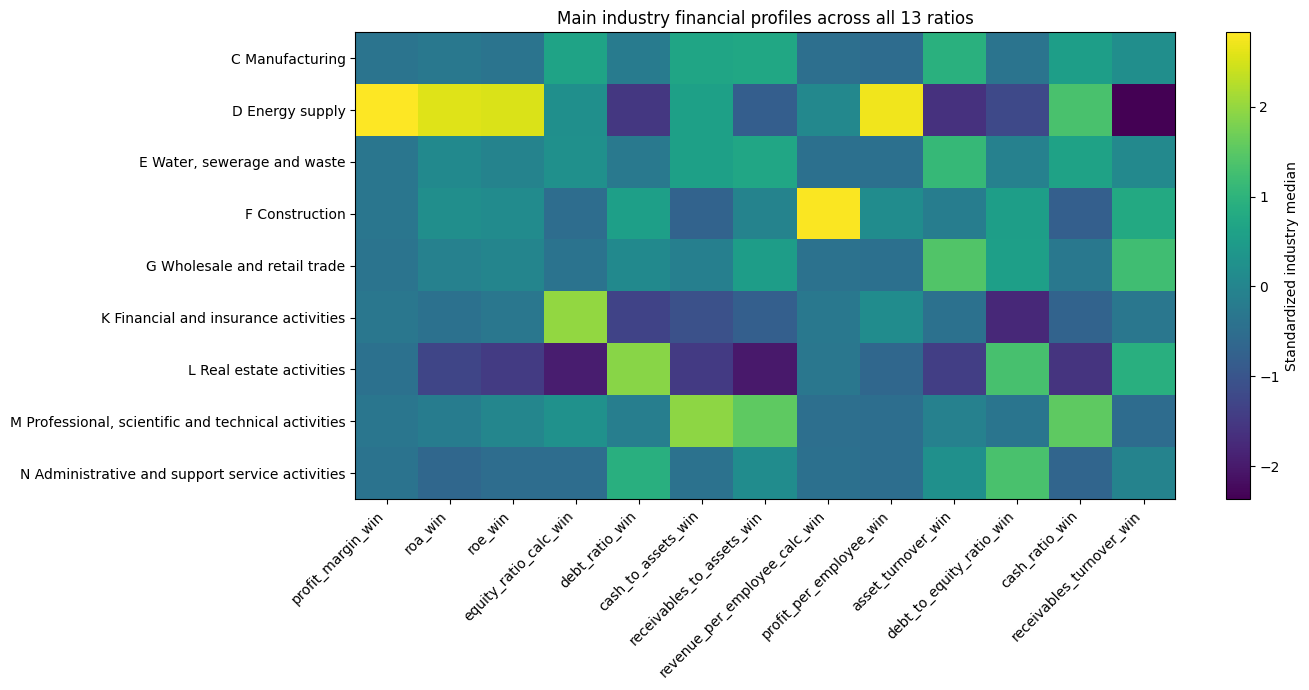

Saved:
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/06_industry_and_ratio_deepdive/figures/06_fig_01_main_industry_all_13_ratio_heatmap.png
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/06_industry_and_ratio_deepdive/figures/06_fig_01_main_industry_all_13_ratio_heatmap.pdf
Data saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/06_industry_and_ratio_deepdive/06_07_industry_all_13_ratio_heatmap_data.csv


In [14]:
if SECTOR_COL is not None:
    heatmap_data = (
        df_main_industries
        .groupby(SECTOR_COL)[ALL_RATIOS]
        .median()
    )

    # Remove ratios that are completely missing
    heatmap_data = heatmap_data.dropna(axis=1, how="all")

    # Standardize each ratio column
    heatmap_z = (heatmap_data - heatmap_data.mean()) / heatmap_data.std(ddof=0)

    heatmap_data_path = os.path.join(OUT_DIR, "06_07_industry_all_13_ratio_heatmap_data.csv")
    heatmap_data.to_csv(heatmap_data_path)

    plt.figure(figsize=(14, 7))
    plt.imshow(heatmap_z, aspect="auto")
    plt.colorbar(label="Standardized industry median")

    plt.xticks(
        ticks=np.arange(len(heatmap_z.columns)),
        labels=heatmap_z.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        ticks=np.arange(len(heatmap_z.index)),
        labels=heatmap_z.index.astype(str)
    )

    plt.title("Main industry financial profiles across all 13 ratios")

    plt.tight_layout()

    fig_png = os.path.join(FIG_DIR, "06_fig_01_main_industry_all_13_ratio_heatmap.png")
    fig_pdf = os.path.join(FIG_DIR, "06_fig_01_main_industry_all_13_ratio_heatmap.pdf")

    plt.savefig(fig_png, dpi=300, bbox_inches="tight")
    plt.savefig(fig_pdf, bbox_inches="tight")
    plt.show()

    print("Saved:")
    print(fig_png)
    print(fig_pdf)
    print("Data saved:", heatmap_data_path)
else:
    print("Sector column not found.")

**Cell 13 - Best and weakest industry by ratio**

In [15]:
if SECTOR_COL is not None:
    ratio_rankings = []

    industry_medians_only = industry_ratio_medians.set_index(SECTOR_COL)

    for ratio in ALL_RATIOS:
        if ratio not in industry_medians_only.columns:
            continue

        s = industry_medians_only[ratio].dropna()

        if s.empty:
            continue

        ratio_rankings.append({
            "ratio": ratio,
            "highest_industry": s.idxmax(),
            "highest_median": s.max(),
            "lowest_industry": s.idxmin(),
            "lowest_median": s.min()
        })

    ratio_rankings = pd.DataFrame(ratio_rankings)

    ratio_rankings_path = os.path.join(OUT_DIR, "06_08_best_and_weakest_industry_by_ratio.csv")
    ratio_rankings.to_csv(ratio_rankings_path, index=False)

    display(ratio_rankings)
    print("Saved:", ratio_rankings_path)
else:
    print("Sector column not found.")

,ratio,highest_industry,highest_median,lowest_industry,lowest_median
0,profit_margin_win,D Energy supply,0.5211,L Real estate activities,0.0000
1,roa_win,D Energy supply,0.1276,L Real estate activities,0.0000
2,roe_win,D Energy supply,0.3184,L Real estate activities,0.0000
3,equity_ratio_calc_win,K Financial and insurance activities,0.5418,L Real estate activities,0.2849
4,debt_ratio_win,L Real estate activities,0.5855,D Energy supply,0.2221
5,cash_to_assets_win,"M Professional, scientific and technical activ...",0.2313,L Real estate activities,0.0443
6,receivables_to_assets_win,"M Professional, scientific and technical activ...",0.2585,L Real estate activities,0.0550
7,revenue_per_employee_calc_win,F Construction,"14,000,000.0000","M Professional, scientific and technical activ...","266,190.4762"
8,profit_per_employee_win,D Energy supply,"95,787.1450",L Real estate activities,10.1197
9,asset_turnover_win,G Wholesale and retail trade,3.3079,D Energy supply,0.2282


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/06_industry_and_ratio_deepdive/06_08_best_and_weakest_industry_by_ratio.csv


In [16]:
ratio_group_conclusions = pd.DataFrame([
    {
        "ratio_group": "Profitability",
        "ratios": "profit_margin_win, roa_win, roe_win",
        "what_to_analyse": "Which industries show higher or lower profitability?",
        "possible_thesis_use": "Main performance comparison across industries."
    },
    {
        "ratio_group": "Capital structure",
        "ratios": "equity_ratio_calc_win, debt_ratio_win, debt_to_equity_ratio_win",
        "what_to_analyse": "Which industries rely more on debt or equity?",
        "possible_thesis_use": "Explains differences in financial risk and balance-sheet structure."
    },
    {
        "ratio_group": "Liquidity",
        "ratios": "cash_to_assets_win, cash_ratio_win",
        "what_to_analyse": "Which industries hold more cash or liquid resources?",
        "possible_thesis_use": "Links liquidity structure to profitability and risk."
    },
    {
        "ratio_group": "Receivables / working capital",
        "ratios": "receivables_to_assets_win, receivables_turnover_win",
        "what_to_analyse": "Which industries have stronger receivables exposure?",
        "possible_thesis_use": "Useful for working-capital interpretation but not central econometric finding."
    },
    {
        "ratio_group": "Efficiency",
        "ratios": "asset_turnover_win",
        "what_to_analyse": "Which industries generate more revenue relative to assets?",
        "possible_thesis_use": "Supports interpretation of margin-turnover trade-off."
    },
    {
        "ratio_group": "Employee productivity",
        "ratios": "revenue_per_employee_calc_win, profit_per_employee_win",
        "what_to_analyse": "Which industries show higher revenue/profit per employee?",
        "possible_thesis_use": "Use only as sub-sample analysis because employee data availability is limited."
    }
])

group_conclusion_path = os.path.join(OUT_DIR, "06_09_ratio_group_conclusion_helper.csv")
ratio_group_conclusions.to_csv(group_conclusion_path, index=False)

display(ratio_group_conclusions)

print("Saved:", group_conclusion_path)

,ratio_group,ratios,what_to_analyse,possible_thesis_use
0,Profitability,"profit_margin_win, roa_win, roe_win",Which industries show higher or lower profitab...,Main performance comparison across industries.
1,Capital structure,"equity_ratio_calc_win, debt_ratio_win, debt_to...",Which industries rely more on debt or equity?,Explains differences in financial risk and bal...
2,Liquidity,"cash_to_assets_win, cash_ratio_win",Which industries hold more cash or liquid reso...,Links liquidity structure to profitability and...
3,Receivables / working capital,"receivables_to_assets_win, receivables_turnove...",Which industries have stronger receivables exp...,Useful for working-capital interpretation but ...
4,Efficiency,asset_turnover_win,Which industries generate more revenue relativ...,Supports interpretation of margin-turnover tra...
5,Employee productivity,"revenue_per_employee_calc_win, profit_per_empl...",Which industries show higher revenue/profit pe...,Use only as sub-sample analysis because employ...


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/06_industry_and_ratio_deepdive/06_09_ratio_group_conclusion_helper.csv


In [17]:
thesis_logic_notes = """
06 INDUSTRY AND RATIO DEEPDIVE — NOTES FOR THESIS

This part broadens the thesis beyond the final econometric model. The econometric model focuses
on the most stable predictors of profit margin, but the descriptive thesis analysis uses all 13 ratios.

The 13 ratios are grouped into six financial themes:
1. Profitability
2. Capital structure
3. Liquidity
4. Receivables / working capital
5. Efficiency
6. Employee productivity

The financial vs non-financial comparison is useful because financial firms have different balance-sheet
structures. Therefore, financial firms are not removed from the descriptive analysis, but they are treated
carefully and used in robustness checks.

The main industry analysis focuses on WZ sectors with sufficient observations. Small industries are not
used for strong conclusions because their medians may be unstable.

The all-ratio industry heatmap provides a compact view of how industries differ across profitability,
capital structure, liquidity, working capital, efficiency, and productivity. This allows the thesis to make
several descriptive conclusions, not only one regression conclusion.

The econometric conclusion remains focused:
- Debt ratio is negatively associated with profit margin.
- Cash-to-assets is positively associated with profit margin.
- Asset turnover is negatively associated with profit margin.
- Detailed industry classification improves model fit.

The descriptive conclusion is broader:
- Industries differ across many financial dimensions.
- Financial firms differ structurally from non-financial firms.
- Some ratios are useful mainly descriptively, while others are stable enough for econometric conclusions.
- Employee ratios should be interpreted only as sub-sample evidence due to lower availability.

This structure avoids over-analysis while still showing that the thesis uses the full richness of the dataset.
"""

notes_path = os.path.join(OUT_DIR, "06_10_thesis_logic_notes.txt")

with open(notes_path, "w") as f:
    f.write(thesis_logic_notes)

print(thesis_logic_notes)
print("Saved:", notes_path)


06 INDUSTRY AND RATIO DEEPDIVE — NOTES FOR THESIS

This part broadens the thesis beyond the final econometric model. The econometric model focuses
on the most stable predictors of profit margin, but the descriptive thesis analysis uses all 13 ratios.

The 13 ratios are grouped into six financial themes:
1. Profitability
2. Capital structure
3. Liquidity
4. Receivables / working capital
5. Efficiency
6. Employee productivity

The financial vs non-financial comparison is useful because financial firms have different balance-sheet
structures. Therefore, financial firms are not removed from the descriptive analysis, but they are treated
carefully and used in robustness checks.

The main industry analysis focuses on WZ sectors with sufficient observations. Small industries are not
used for strong conclusions because their medians may be unstable.

The all-ratio industry heatmap provides a compact view of how industries differ across profitability,
capital structure, liquidity, working capi